# Baseline Models

Two baseline models were trained to establish reference performance before moving to a neural network: Logistic Regression and Random Forest, both using class_weight='balanced' to address the ~78/22 class imbalance identified in EDA.

## 1. Logistic Regression

Loaded data via local (30000 rows, 25 columns).
=== Logistic Regression (val) ===
Precision: 0.4444  (of predicted defaulters, how many actually defaulted)
Recall:    0.6231  (of actual defaulters, how many did we catch)
F1:        0.5188  (harmonic mean of precision and recall)
ROC-AUC:   0.7499  (ranking quality across all thresholds)

              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3505
     Default       0.44      0.62      0.52       995

    accuracy                           0.74      4500
   macro avg       0.66      0.70      0.67      4500
weighted avg       0.78      0.74      0.76      4500



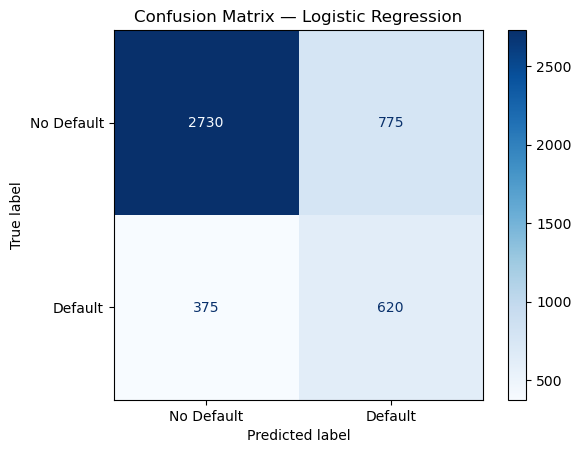

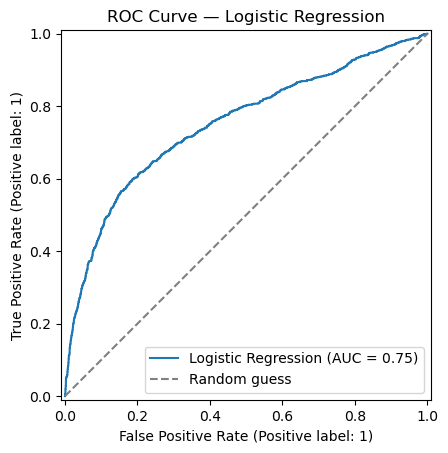

In [1]:
import sys
sys.path.append("..")

from src.data_loader import load_raw_data
from src.preprocessing import run_preprocessing_pipeline
from src.evaluate import evaluate_classifier, plot_confusion_matrix, plot_roc_curve
from sklearn.linear_model import LogisticRegression

df = load_raw_data()
splits, artifacts = run_preprocessing_pipeline(df)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(splits.X_train, splits.y_train)

y_pred = model.predict(splits.X_val)
y_pred_proba = model.predict_proba(splits.X_val)[:, 1]

results = evaluate_classifier(splits.y_val, y_pred, y_pred_proba, model_name="Logistic Regression (val)")
plot_confusion_matrix(splits.y_val, y_pred, model_name="Logistic Regression")
plot_roc_curve(splits.y_val, y_pred_proba, model_name="Logistic Regression")

In [2]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': splits.X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.head(10))

      feature  coefficient
5       PAY_0     0.471389
17   PAY_AMT1    -0.238037
16  BILL_AMT6     0.194720
0   LIMIT_BAL    -0.166768
7       PAY_3     0.161107
19   PAY_AMT3    -0.158760
18   PAY_AMT2    -0.127995
20   PAY_AMT4    -0.113284
3    MARRIAGE    -0.099171
13  BILL_AMT3    -0.096182


## 2. Random Forest
Why Random Forest as a second baseline, specifically

A few things it lets us check that Logistic Regression can't:

1. It's not sensitive to multicollinearity the way Logistic Regression is — so if the BILL_AMT4/5/6 coefficient weirdness we just discussed was purely a collinearity artifact, Random Forest's feature importances should look "cleaner" and track EDA correlations more directly.
2. It doesn't need scaled features — trees split on thresholds, not magnitudes, so scaling is irrelevant to them (unlike Logistic Regression and the upcoming neural net, where it mattered a lot). I'm still passing it the scaled data below for simplicity/consistency, but know that this step was optional for this specific model.
3. It can capture non-linear relationships and feature interactions — Logistic Regression assumes each feature contributes independently and linearly to the outcome; Random Forest doesn't have that constraint. If Random Forest meaningfully outperforms Logistic Regression, that's a signal the true relationship in the data isn't purely linear.

=== Random Forest (val) ===
Precision: 0.6962  (of predicted defaulters, how many actually defaulted)
Recall:    0.3317  (of actual defaulters, how many did we catch)
F1:        0.4493  (harmonic mean of precision and recall)
ROC-AUC:   0.7716  (ranking quality across all thresholds)

              precision    recall  f1-score   support

  No Default       0.83      0.96      0.89      3505
     Default       0.70      0.33      0.45       995

    accuracy                           0.82      4500
   macro avg       0.77      0.65      0.67      4500
weighted avg       0.80      0.82      0.79      4500



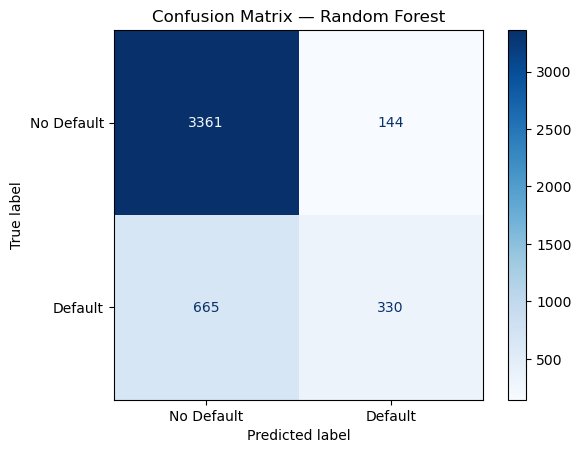

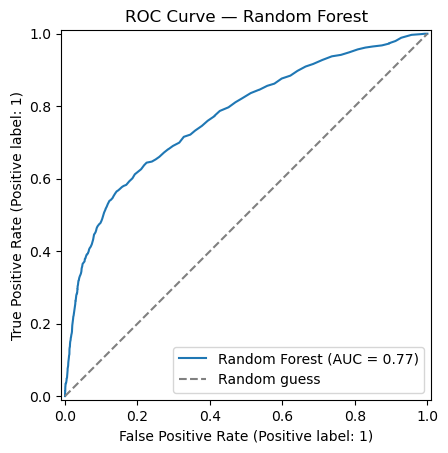

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,       # number of trees — more trees = more stable predictions, at the cost of training time
    class_weight='balanced', # same imbalance-handling concept as Logistic Regression, applied per tree
    random_state=42,
    n_jobs=-1                # use all available CPU cores to train trees in parallel — RF trees are independent, so this is "free" speed
)
rf.fit(splits.X_train, splits.y_train)

y_pred_rf = rf.predict(splits.X_val)
y_pred_proba_rf = rf.predict_proba(splits.X_val)[:, 1]

results_rf = evaluate_classifier(splits.y_val, y_pred_rf, y_pred_proba_rf, model_name="Random Forest (val)")
plot_confusion_matrix(splits.y_val, y_pred_rf, model_name="Random Forest")
plot_roc_curve(splits.y_val, y_pred_proba_rf, model_name="Random Forest")

In [5]:
importance_df = pd.DataFrame({
    'feature': splits.X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

      feature  importance
5       PAY_0    0.096475
0   LIMIT_BAL    0.064600
4         AGE    0.063134
11  BILL_AMT1    0.062035
12  BILL_AMT2    0.053757
18   PAY_AMT2    0.053134
17   PAY_AMT1    0.051875
13  BILL_AMT3    0.050795
14  BILL_AMT4    0.049485
19   PAY_AMT3    0.048916


## Baseline Model Comparison


| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 0.45 | 0.70 |
| Recall | 0.63 | 0.33 |
| F1 | 0.52 | 0.45 |
| ROC-AUC | 0.75 | 0.77 |

The two models show a clear precision/recall trade-off rather than one being strictly better than the other. Logistic Regression casts a wider net — it catches 63% of actual defaulters, at the cost of a lower precision (45% of its "default" predictions are correct). Random Forest is more conservative — only 33% recall, but 70% precision when it does flag a client as high-risk. This difference stems from how class_weight='balanced' is applied differently across model types: it directly reweights every training example in Logistic Regression's loss function, but in Random Forest it's applied per split within trees trained on bootstrapped samples, which dilutes its effect given how few minority-class examples land in some individual samples.

Random Forest achieves a marginally higher ROC-AUC (0.77 vs. 0.75), indicating slightly better overall ranking ability across thresholds, but Logistic Regression achieves a higher F1 (0.52 vs. 0.45) at the default 0.5 threshold, driven by its stronger recall. Given the framing of this problem — a bank wanting to identify at-risk clients early for intervention — recall on the default class is arguably the more business-relevant metric, which would favor Logistic Regression's behavior at this threshold. However, Random Forest's threshold could be tuned (lowered) to trade some precision for more recall if needed, so this isn't a fixed limitation of the model itself.

Both models' most important features were broadly consistent with EDA: PAY_0 (most recent repayment status) was the strongest predictor in both. LIMIT_BAL also ranked highly in both, consistent with its EDA correlation. Random Forest's feature importance ranking should be read with one caveat: its built-in feature_importances_ is biased toward continuous, high-cardinality features (e.g. AGE, BILL_AMT*), which can rank higher than their true predictive value simply because they offer more possible split points — not necessarily because they're more informative than EDA suggested. A more reliable measure (permutation importance) was not computed at this stage but would be worth using if feature importance needed to be reported with confidence.

These two baselines give us reference points to compare the neural network against: any TensorFlow model we build should be judged not just on its absolute metrics, but on whether it meaningfully improves over ~0.75–0.77 ROC-AUC and ~0.45–0.52 F1 — otherwise the added complexity of a neural network wouldn't be justified for this problem.